<a href="https://colab.research.google.com/github/DenisDrobyshev/universum/blob/master/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%969_%D0%98%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8_YOLOv12_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87_%D0%B4%D0%B5%D1%82%D0%B5%D0%BA%D1%86%D0%B8%D0%B8_%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №9. Использование модели YOLOv26 для решение задач детекции и классификации**

## **Задание 1. Знакомство с новейшей версией модели YOLO**

- Ознакомьтесь с технической документацией по новейшей версии модели YOLOv26: https://docs.ultralytics.com/ru/models/yolo26/

- Рассмотрите пример обучения этой модели c использованием датасетов, созданных в Roboflow: https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/train-yolo26-object-detection-on-custom-dataset.ipynb?ref=blog.roboflow.com

### **Ответьте на вопрос: Какие принципиальные отличия появились в модели YOLOv26 относительно предыдущих версий?**

Главное отличие YOLOv26 от предыдущих версий — это полный переход на "сквозную" (End-to-End) архитектуру без использования Non-Maximum Suppression (NMS)

YOLOv26 достигает более высокой точности на небольших объектах, обеспечивает бесшовное развертывание и работает до 43% быстрее на CPU, что делает YOLO26 одной из самых практичных и удобных для развертывания моделей YOLO на сегодняшний день для сред с ограниченными ресурсами.

*Примечание:* для каждого последующего задания, в конечном итоге, необходимо сформировать обученную модель и задеплоить её на сервисе **RoboFlow**



## **Задание 2. Найдите готовый датасет для детекции объектов и обучите на нем модель YOLOv26:**

- Для удобства работы с датасетом и деплоя модели используйте сервис [RoboFlow](https://roboflow.com/)

In [ ]:
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 147.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="hQAwS7KOn08k9jEKFyI1")

project = rf.workspace("material-identification").project("garbage-classification-3")
dataset = project.version(2).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to GARBAGE-CLASSIFICATION-3-2 in yolov8:: 100%|██████████| 20940/20940 [00:02<00:00, 7778.05it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import yaml

# читаем data.yaml
with open(dataset.location + "/data.yaml", 'r') as f:
    data_yaml = yaml.safe_load(f)

print("Количество классов:", data_yaml['nc'])
print("Список классов:")

for i, name in enumerate(data_yaml['names']):
    print(f"{i}: {name}")

Количество классов: 6
Список классов:
0: BIODEGRADABLE
1: CARDBOARD
2: GLASS
3: METAL
4: PAPER
5: PLASTIC


In [ ]:
from ultralytics import YOLO

# Загружаем предобученную модель
model = YOLO("yolo26n.pt")

# Запуск обучения
model.train(
    data=dataset.location + "/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    name="object_detection_model"
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/GARBAGE-CLASSIFICATION-3-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=object_detection_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fb06add8830>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
best_model_path = "runs/detect/object_detection_model/weights/best.pt"
print("Модель сохранена здесь:", best_model_path)

Модель сохранена здесь: runs/detect/object_detection_model/weights/best.pt


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving maxresdefault (1).jpg to maxresdefault (1).jpg


In [ ]:
from ultralytics import YOLO

# загружаем обученную модель
model = YOLO(best_model_path)

# берем имя загруженного файла
image_path = list(uploaded.keys())[0]

# делаем предсказание
results = model.predict(
    source=image_path,
    conf=0.25,
    save=True
)


image 1/1 /content/maxresdefault (1).jpg: 384x640 9 METALs, 1 PLASTIC, 73.4ms
Speed: 1.6ms preprocess, 73.4ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict


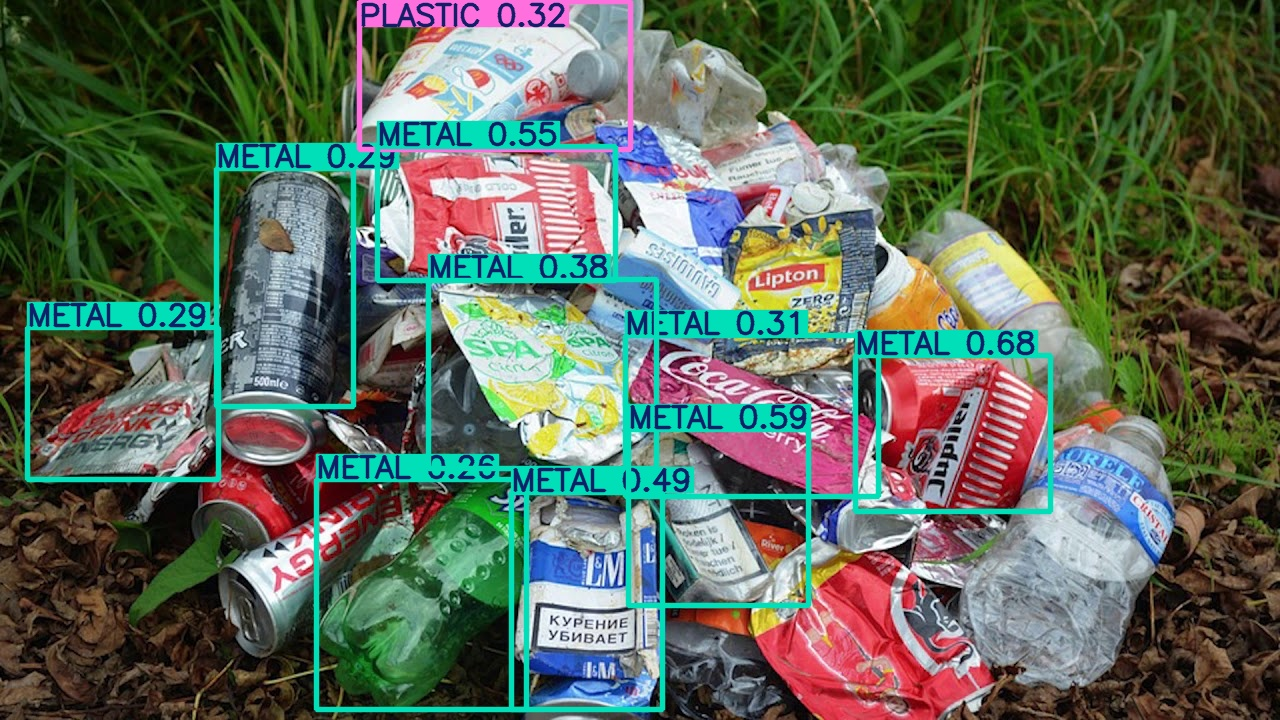

In [ ]:
from IPython.display import Image, display
import glob

result_image = glob.glob("runs/detect/predict/*.jpg")[0]

display(Image(filename=result_image))

In [ ]:
import roboflow

WORKSPACE_NAME = "dennys-workspace-fm2bf"
PROJECT_NAME = "fish-cgcm5"
VERSION_NUMBER = "1"
dir = "best.pt"

# Проверяем, что авторизация выполнена
rf = roboflow.Roboflow(api_key="hQAwS7KOn08k9jEKFyI1")

# Получаем проект
project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)
version = project.version(VERSION_NUMBER)

print(f"Проект: {PROJECT_NAME}")
print(f"Версия: {VERSION_NUMBER}")
print(f"Путь к обученной модели: {dir}")

loading Roboflow workspace...
loading Roboflow project...
Проект: fish-cgcm5
Версия: 1
Путь к обученной модели: best.pt


In [ ]:
import os
from pathlib import Path

model_file = "best.pt"

# Создаем правильную структуру директорий
model_dir = "model_for_deploy"
weights_dir = os.path.join(model_dir, "weights")
os.makedirs(weights_dir, exist_ok=True)

print("\n" + "=" * 50)
print("Модель успешно загружена в Roboflow!")
print(f"Model ID: {PROJECT_NAME}")


Модель успешно загружена в Roboflow!
Model ID: fish-cgcm5


## **Задание 3. Сформируйте свой датасет для детекции объектов и обучите на нем модель YOLOv26**



Требования к датасету:

- Количество изображений в датасете: минимум 90
- Количество классов: более 2х
- Обязательно должны присутствовать изображения, содержащие несколько классов одновременно


*Примечание: Формирование датасета включает в себя поиск изображений и ручное аннотирование объектов на изображениях.*

In [1]:
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 124.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="hQAwS7KOn08k9jEKFyI1")

project = rf.workspace("dennys-workspace-fm2bf").project("fishdetection-avss8")
dataset = project.version(2).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov8 in progress : 0.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to FishDetection-2 in yolov8:: 100%|██████████| 315/315 [00:00<00:00, 9725.33it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import yaml

# читаем data.yaml
with open(dataset.location + "/data.yaml", 'r') as f:
    data_yaml = yaml.safe_load(f)

print("Количество классов:", data_yaml['nc'])
print("Список классов:")

for i, name in enumerate(data_yaml['names']):
    print(f"{i}: {name}")

Количество классов: 3
Список классов:
0: carp
1: osetr
2: trout


Пример изображения:


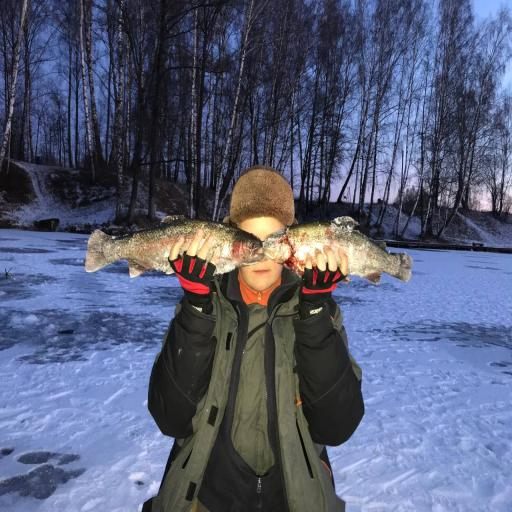

In [5]:
import os
import random
from IPython.display import Image, display

images_path = dataset.location + "/train/images"
random_image = random.choice(os.listdir(images_path))

print("Пример изображения:")
display(Image(filename=os.path.join(images_path, random_image)))

In [6]:
from ultralytics import YOLO

# Загружаем предобученную модель
model = YOLO("yolo26n.pt")

# Запуск обучения
model.train(
    data=dataset.location + "/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    name="fish_detect_model"
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FishDetection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fish_detect_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79e20fad49b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [40]:
best_model_path = "/content/runs/detect/fish_detect_model/weights/best.pt"
print("Модель сохранена здесь:", best_model_path)

Модель сохранена здесь: /content/runs/detect/fish_detect_model/weights/best.pt


In [39]:
from ultralytics import YOLO

# Загружаем твои веса
model = YOLO("/content/runs/detect/fish_detect_model/weights/best.pt")

# Продолжаем обучение — total получится 50 эпох (20 было + 30 новых)
results = model.train(
    data=dataset.location + "/data.yaml",
    epochs=60,
    imgsz=640,
    batch=16,
    name="fish_detect_model",
    resume=True           # ✅ ключевой параметр — продолжить с сохранённой точки
)

best_model_path = "/content/runs/detect/fish_detect_model/weights/best.pt"
print("Обновлённая модель:", best_model_path)

WARNING ⚠️ model '/content/runs/detect/fish_detect_model/weights/best.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FishDetection-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0

In [77]:
from google.colab import files

uploaded = files.upload()

Saving trout36.jpg to trout36.jpg


In [78]:
old_model_path = "/content/runs/detect/fish_detect_model/weights/best.pt"  # старая (mAP 0.867)
new_model_path = "/content/runs/detect/fish_final/weights/best.pt"        # новая (trout R 0.49)

# Выбери какую тестировать (поменяй если надо)
MODEL_PATH = new_model_path  # или old_model_path

model = YOLO(MODEL_PATH)

In [79]:
from ultralytics import YOLO

# загружаем обученную модель
model = YOLO(MODEL_PATH)

# берем имя загруженного файла
image_path = list(uploaded.keys())[0]

# делаем предсказание
results = model.predict(
    source=image_path,
    conf=0.25,
    save=True
)


image 1/1 /content/trout36.jpg: 640x480 2 trouts, 9.9ms
Speed: 1.9ms preprocess, 9.9ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-23


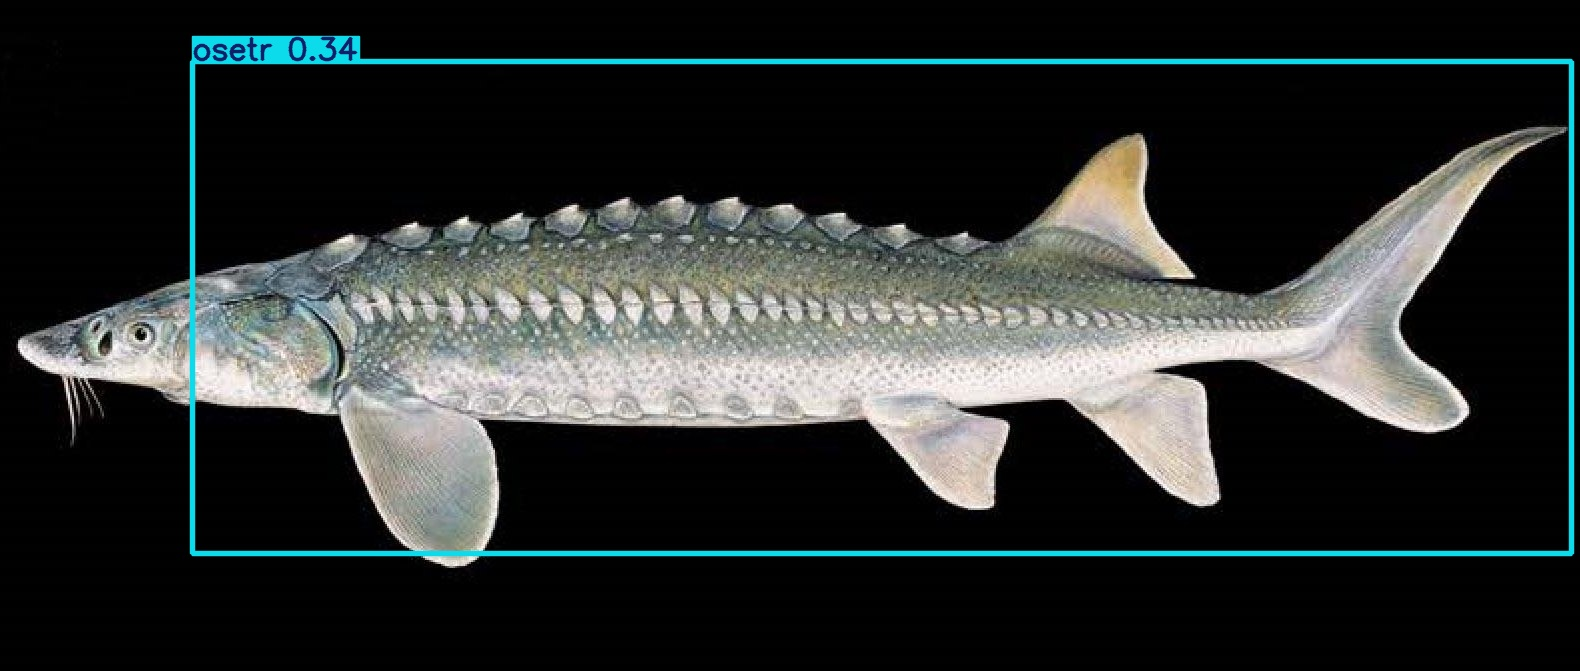

In [16]:
from IPython.display import Image, display
import glob

result_image = glob.glob("runs/detect/predict-3/*.jpg")[0]

display(Image(filename=result_image))

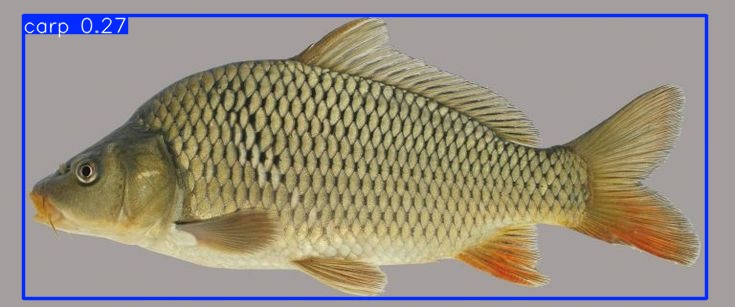

In [19]:
from IPython.display import Image, display
import glob

result_image = glob.glob("runs/detect/predict-4/*.jpg")[0]

display(Image(filename=result_image))

In [ ]:
from IPython.display import Image, display
import glob

result_image = glob.glob("runs/detect/predict-4/*.jpg")[0]

display(Image(filename=result_image))

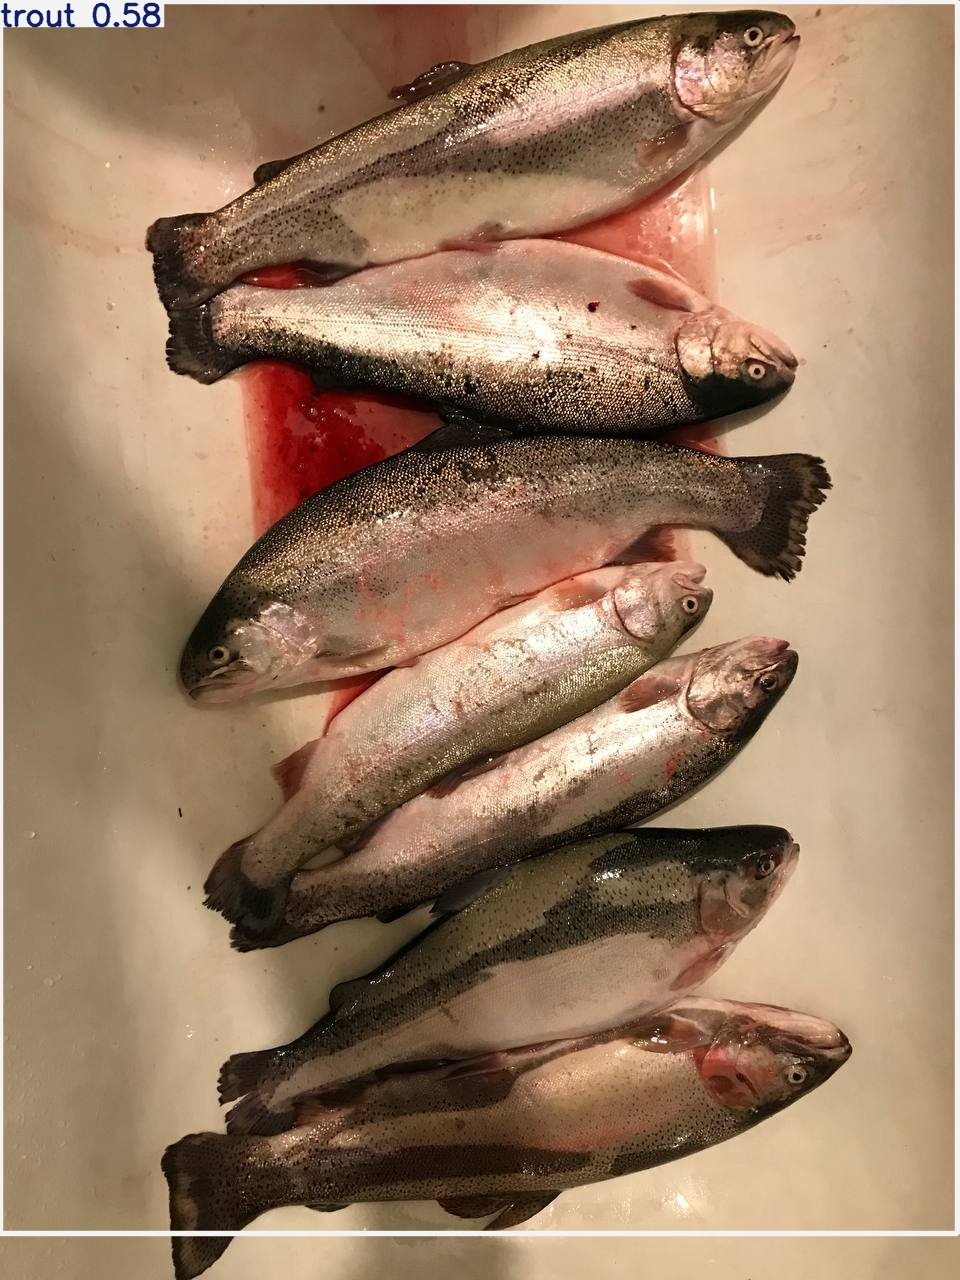

In [76]:
from IPython.display import Image, display
import glob

result_image = glob.glob("runs/detect/predict-22/*.jpg")[0]

display(Image(filename=result_image))

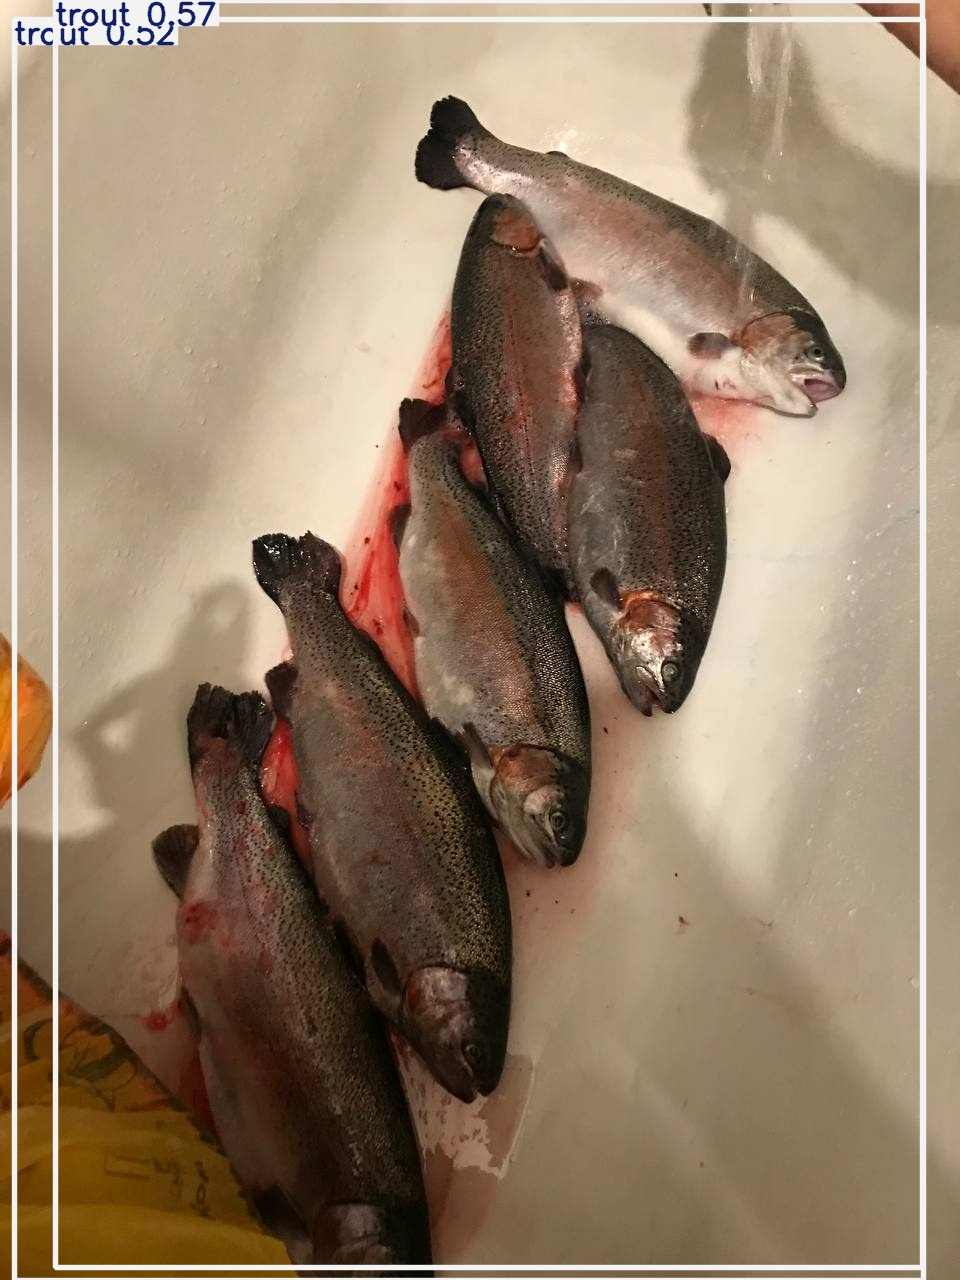

In [80]:
from IPython.display import Image, display
import glob

result_image = glob.glob("runs/detect/predict-23/*.jpg")[0]

display(Image(filename=result_image))

In [63]:
# Дублируем trout-изображения для баланса
import os
import shutil

train_img = os.path.join(dataset.location, "train", "images")
train_lbl = os.path.join(dataset.location, "train", "labels")

trout_images = []
for lbl_file in os.listdir(train_lbl):
    if lbl_file.endswith('.txt'):
        with open(os.path.join(train_lbl, lbl_file), 'r') as f:
            if any(line.startswith('2 ') for line in f.readlines()):
                stem = lbl_file.replace('.txt', '')
                trout_images.append(stem)

print(f"Trout изображений: {len(trout_images)}")

# Дублируем каждое 3 раза
for stem in trout_images:
    for ext in ['.jpg', '.jpeg', '.png', '.JPG']:
        img_path = os.path.join(train_img, stem + ext)
        if os.path.exists(img_path):
            for i in range(3):
                shutil.copy(img_path, os.path.join(train_img, f"{stem}_dup{i}{ext}"))
                shutil.copy(os.path.join(train_lbl, f"{stem}.txt"),
                          os.path.join(train_lbl, f"{stem}_dup{i}.txt"))
            break

# Статистика после дублирования
from collections import Counter
class_counter = Counter()
for lbl_file in os.listdir(train_lbl):
    if lbl_file.endswith('.txt'):
        with open(os.path.join(train_lbl, lbl_file), 'r') as f:
            for line in f:
                class_counter[int(line[0])] += 1

print(f"Objects: carp={class_counter[0]}, osetr={class_counter[1]}, trout={class_counter[2]}")

Trout изображений: 42
✅ Дублирование завершено!
Objects: carp=41, osetr=26, trout=168


In [64]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/fish_detect_model/weights/best.pt")

results = model.train(
    data=dataset.location + "/data.yaml",
    epochs=15,                # быстро, всего 15 эпох
    imgsz=640,
    batch=16,
    name="fish_final",
    lr0=0.0003,              # очень низкий LR, только докрутить
    lrf=0.00001,
    warmup_epochs=1,
    cos_lr=True,
    hsv_h=0.04,              # меняем оттенок (форель бывает разного цвета)
    hsv_s=0.9,               # насыщенность
    degrees=30,              # крутим сильнее
    translate=0.2,
    scale=0.8,               # разный масштаб
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.3,               # смешиваем картинки
    optimizer="AdamW"
)

best_model_path = "/content/runs/detect/fish_final/weights/best.pt"
print(f"✅ Дообучение завершено! Модель: {best_model_path}")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/FishDetection-2/data.yaml, degrees=30, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.04, hsv_s=0.9, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=1e-05, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=/content/runs/detect/fish_detect_model/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fish_final, nbs=64, nms=False, opset=None, optimize=F

In [81]:
import roboflow

WORKSPACE_NAME = "dennys-workspace-fm2bf"
PROJECT_NAME = "fishdetection-avss8"
VERSION_NUMBER = "2"
dir = "/content/runs/detect/fish_final/weights/best.pt"

# Проверяем, что авторизация выполнена
rf = roboflow.Roboflow(api_key="hQAwS7KOn08k9jEKFyI1")

# Получаем проект
project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)
version = project.version(VERSION_NUMBER)

print(f"Проект: {PROJECT_NAME}")
print(f"Версия: {VERSION_NUMBER}")
print(f"Путь к обученной модели: {dir}")

loading Roboflow workspace...
loading Roboflow project...
Проект: fishdetection-avss8
Версия: 2
Путь к обученной модели: /content/runs/detect/fish_final/weights/best.pt


In [82]:
import os
from pathlib import Path
import shutil

model_file = "/content/runs/detect/fish_final/weights/best.pt"

# Создаем правильную структуру директорий
model_dir = "model_for_deploy"
weights_dir = os.path.join(model_dir, "weights")
os.makedirs(weights_dir, exist_ok=True)

# Копируем файл в нужное место
shutil.copy(model_file, os.path.join(weights_dir, "best.pt"))

# Теперь развертываем
version.deploy(
    model_type="yolo26n",
    model_path=model_dir
)

print("\n" + "=" * 50)
print("✅ Модель успешно загружена в Roboflow!")
print(f"Workspace: {WORKSPACE_NAME}")
print(f"Project: {PROJECT_NAME}")
print(f"Version: {VERSION_NUMBER}")
print("=" * 50)

View the status of your deployment at: https://app.roboflow.com/dennys-workspace-fm2bf/fishdetection-avss8/2
Share your model with the world at: https://universe.roboflow.com/dennys-workspace-fm2bf/fishdetection-avss8/model/2

✅ Модель успешно загружена в Roboflow!
Workspace: dennys-workspace-fm2bf
Project: fishdetection-avss8
Version: 2


## **Задание 4 (для магистрантов). Обучите модель YOLOv26 на датасете [RSD-GOD](https://github.com/Dr-Zhuang/geospatial-object-detection). Затем самостоятельно сформируйте тестовые данные (не менее 50 изображений с аннотациями) и оцените качество обученной модели:**



**Прямая ссылка на загрузку датасета: [загрузить](https://drive.google.com/open?id=1ttvSta0BRxW7tTV_st89vSb_obHVre34)**

**Ссылка на датасет в среде roboflow universe:** https://universe.roboflow.com/animals-sqrdn/rsd-god

 *Примечание: для поиска данных удобно использовать сервис Google Earth/Google Earth Engine*

In [ ]:
# Ваш код